### 验证时间管理能力 计算能力 能不能在长期阶段影响ELO

In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle
from functools import reduce

db_path = r"C:\sqlite3\chess.db"
table = 'games'

In [2]:
conn = sqlite3.connect(db_path)
df = pd.read_sql(f'SELECT uid, Date, White, Black, WhiteElo, BlackElo FROM {table}', conn)
df.head()

,uid,Date,White,Black,WhiteElo,BlackElo
0,1,2025.04.01,Petra Kejzar,Daniel Barria,2177,2637
1,2,2025.04.01,Nataliya Buksa,Jorge Carlos Antonio,2639,2195
2,3,2025.04.01,Hubert Zieba,Nikolaos Skiadopoulos,2607,2049
3,4,2025.04.01,Karina Ambartsumova,Nino Maisuradze,2709,2358
4,5,2025.04.01,Alexander Donchenko,Andriy Diachek,2835,2494


In [3]:
# 将games表转为选手时间序列
# 1. 提取白方数据
white_players = df[['White', 'Date', 'WhiteElo']].rename(
    columns={'White': 'Player', 'Date': 'Date', 'WhiteElo': 'ELO'}
)
# 2. 提取黑方数据
black_players = df[['Black', 'Date', 'BlackElo']].rename(
    columns={'Black': 'Player', 'Date': 'Date', 'BlackElo': 'ELO'}
)

# 3. 合并并转为日期格式
player_history = pd.concat([white_players, black_players])
player_history['Date'] = pd.to_datetime(player_history['Date'])
player_history.head()

,Player,Date,ELO
0,Petra Kejzar,2025-04-01,2177
1,Nataliya Buksa,2025-04-01,2639
2,Hubert Zieba,2025-04-01,2607
3,Karina Ambartsumova,2025-04-01,2709
4,Alexander Donchenko,2025-04-01,2835


In [4]:
player_history.shape

(2035416, 3)

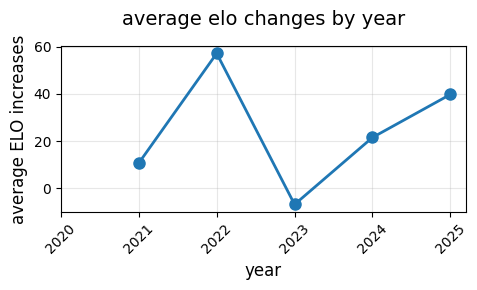

每年平均ELO：
   Year      ELO  ELO_Growth
0  2020  2472.53         NaN
1  2021  2483.19       10.67
2  2022  2540.36       57.17
3  2023  2533.49       -6.87
4  2024  2555.01       21.52
5  2025  2594.77       39.77


In [5]:
# 处理日期，提取年份
player_history['Date'] = pd.to_datetime(player_history['Date'])  # 转成日期格式
player_history['Year'] = player_history['Date'].dt.year  # 提取年份
# 按年份计算【所有选手的平均ELO】
yearly_avg_elo = player_history.groupby('Year')['ELO'].mean().reset_index()
# 计算每年的ELO增幅
yearly_avg_elo['ELO_Growth'] = yearly_avg_elo['ELO'].diff()
plt.figure(figsize=(5, 3))
plt.plot(
    yearly_avg_elo['Year'], 
    yearly_avg_elo['ELO_Growth'], 
    marker='o', 
    linewidth=2, 
    markersize=8, 
    color='#1f77b4'
)
plt.title('average elo changes by year', fontsize=14, pad=15)
plt.xlabel('year', fontsize=12)
plt.ylabel('average ELO increases', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_avg_elo['Year'], rotation=45)  # 年份不重叠
plt.tight_layout()
plt.show()

print("每年平均ELO：")
print(yearly_avg_elo[['Year', 'ELO', 'ELO_Growth']].round(2))

In [6]:
player_history.head()

,Player,Date,ELO,Year
0,Petra Kejzar,2025-04-01,2177,2025
1,Nataliya Buksa,2025-04-01,2639,2025
2,Hubert Zieba,2025-04-01,2607,2025
3,Karina Ambartsumova,2025-04-01,2709,2025
4,Alexander Donchenko,2025-04-01,2835,2025


<Axes: >

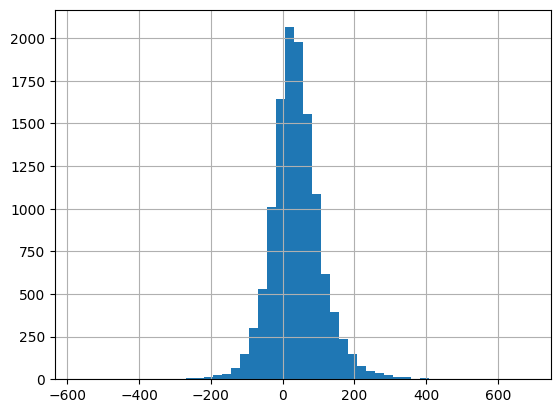

In [7]:
# 筛选出至少跨越3年的选手
valid_players = (
    player_history.groupby('Player')['Year'].nunique()
    .loc[lambda x: x >= 3]
    .index
)

# 2. 统计每个选手每年的平均 ELO 和 参赛场次
# 这里直接生成年度统计表
player_year = (
    player_history[player_history['Player'].isin(valid_players)]
    .groupby(['Player', 'Year'])
    .agg(
        mean_ELO=('ELO', 'mean'),
        game_count=('ELO', 'count')
    )
    .reset_index()
)

# 只保留一年内至少下过 5 场（或更多）的记录
# 这样算的平均分才不容易因为某一场的输赢产生巨大偏差
player_year = player_year[player_year['game_count'] >= 5]

# 算增长率
# 注意：因为过滤了场次，有些年份可能断开了，shift(-1) 依然有效，但需确保是时间顺序
player_year = player_year.sort_values(['Player', 'Year'])
player_year['ELO_next'] = player_year.groupby('Player')['mean_ELO'].shift(-1)
player_year['ELO_growth'] = player_year['ELO_next'] - player_year['mean_ELO']
player_year['ELO_growth'].hist(bins=50)

## rolling temporal prediction（滚动时间预测）
#### features_t  →  ELO_growth_{t→t+1}

### 先确定观察的选手有谁，要比赛多的

In [8]:
player_history.head()

,Player,Date,ELO,Year
0,Petra Kejzar,2025-04-01,2177,2025
1,Nataliya Buksa,2025-04-01,2639,2025
2,Hubert Zieba,2025-04-01,2607,2025
3,Karina Ambartsumova,2025-04-01,2709,2025
4,Alexander Donchenko,2025-04-01,2835,2025


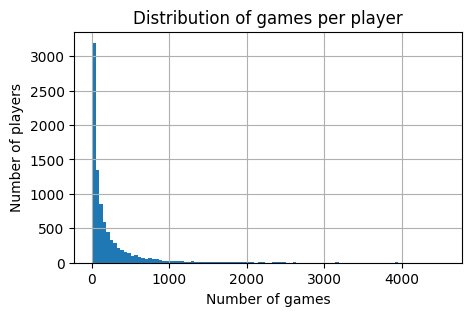

In [9]:
player_history['Player'] = player_history['Player'].str.lower().str.strip()
player_counts = (player_history.groupby('Player').size().reset_index(name='game_count'))
plt.figure(figsize=(5,3))
player_counts['game_count'].hist(bins=100)
plt.xlabel('Number of games')
plt.ylabel('Number of players')
plt.title('Distribution of games per player')
plt.show()

In [10]:
# 看不同分位数的人都总共比过多少场
print(player_counts['game_count'].quantile([0.5, 0.75, 0.8, 0.9, 0.95, 1.00]))
# 看比赛总数超过200的人有多少
threshold = 200
active_players = player_counts[player_counts['game_count'] >= threshold]['Player']
print(len(active_players))

0.50      86.0
0.75     249.0
0.80     322.0
0.90     588.4
0.95     953.0
1.00    4551.0
Name: game_count, dtype: float64
2659


In [11]:
active_player_history = player_history[player_history['Player'].isin(active_players)]

## 判断活跃的选手 active_players 中，有多少人能满足“周频”更新

C:\Users\Administrator\AppData\Local\Temp\ipykernel_19792\2250683811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_player_history['Date'] = pd.to_datetime(active_player_history['Date'])


平均每位选手有 624.0 条记录
选手的平均比赛间隔为 3.0 天


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19792\2250683811.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_player_history['Week_Continuous'] = (active_player_history['Date'] - active_player_history['Date'].min()).dt.days // 7


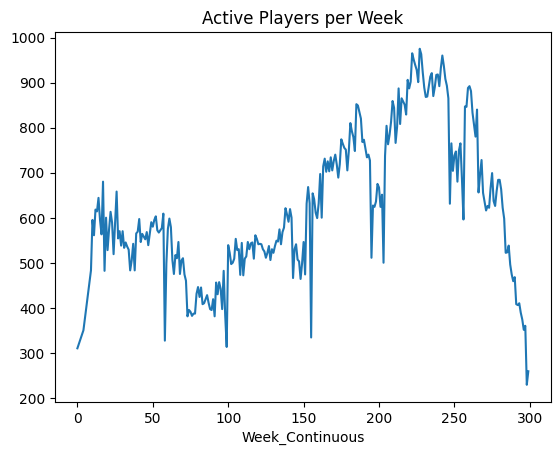

In [12]:
# 1. 确保 Date 是日期格式
active_player_history['Date'] = pd.to_datetime(active_player_history['Date'])

# 2. 计算每个选手平均多久出现一次（采样密度）
player_counts = active_player_history.groupby('Player')['Date'].count()
player_timespan = active_player_history.groupby('Player')['Date'].apply(lambda x: (x.max() - x.min()).days)
avg_gap = player_timespan / player_counts

print(f"平均每位选手有 {player_counts.mean():.1f} 条记录")
print(f"选手的平均比赛间隔为 {avg_gap.mean():.1f} 天")

# 3. 看看每周到底有多少活跃选手
active_player_history['Week_Continuous'] = (active_player_history['Date'] - active_player_history['Date'].min()).dt.days // 7
active_players_per_week = active_player_history.groupby('Week_Continuous')['Player'].nunique()

active_players_per_week.plot(title='Active Players per Week')
plt.show()

### 按周计数，使用连续周

In [13]:
active_player_history.head()

,Player,Date,ELO,Year,Week_Continuous
1,nataliya buksa,2025-04-01,2639,2025,268
2,hubert zieba,2025-04-01,2607,2025,268
3,karina ambartsumova,2025-04-01,2709,2025,268
4,alexander donchenko,2025-04-01,2835,2025,268
5,lovro novosel,2025-04-01,2636,2025,268


In [14]:
weekly_active = active_player_history.copy()

# 1. 统一计算连续周
# 这里的 min_date 就是你要找的“时间基准”
min_date = active_player_history['Date'].min()

# --- 验证代码开始 ---
print("-" * 30)
print(f"时间基准验证：")
print(f"数据集的第 0 周起点日期是: {min_date}")
# 如果你想看这个日期是周几（Titled Tuesday 通常是周二）
print(f"这一天是星期: {min_date.day_name()}") 
print("-" * 30)
# --- 验证代码结束 ---

# 1. 确保独立副本，计算周索引
weekly_active['Week_Idx'] = (weekly_active['Date'] - min_date).dt.days // 7

# 2. 聚合：计算每个玩家“自己”在这一周的平均 ELO
# 这一步会自动把一个玩家在同一周打的多场比赛合并为一行
weekly_active = weekly_active.groupby(['Player', 'Week_Idx']).agg(
    Player_Weekly_ELO=('ELO', 'mean'),
    Games_This_Week=('ELO', 'count')
).reset_index()

# 3. 排序，确保 shift 逻辑正确
weekly_active = weekly_active.sort_values(['Player', 'Week_Idx'])

# 4. 获取该玩家“下一次参赛”的周索引和分数
weekly_active['Next_Week_Idx'] = weekly_active.groupby('Player')['Week_Idx'].shift(-1)
weekly_active['Next_Weekly_ELO'] = weekly_active.groupby('Player')['Player_Weekly_ELO'].shift(-1)

# 5. 计算 ELO_Change
# 逻辑：仅当 (下一次参赛周 - 当前周 == 1) 时计算分差，否则为 NaN
weekly_active['ELO_Change'] = np.where(
    (weekly_active['Next_Week_Idx'] - weekly_active['Week_Idx']) == 1,
    weekly_active['Next_Weekly_ELO'] - weekly_active['Player_Weekly_ELO'],
    np.nan
)

------------------------------
时间基准验证：
数据集的第 0 周起点日期是: 2020-02-05 00:00:00
这一天是星期: Wednesday
------------------------------


In [40]:
# del active_player_history
del active_players_per_week
gc.collect()

5519

In [15]:
weekly_active.head()

,Player,Week_Idx,Player_Weekly_ELO,Games_This_Week,Next_Week_Idx,Next_Weekly_ELO,ELO_Change
0,4empechement,63,2477.000000,11,70.0,2401.363636,NaN
1,4empechement,70,2401.363636,11,71.0,2373.727273,-27.636364
2,4empechement,71,2373.727273,11,77.0,2386.000000,NaN
3,4empechement,77,2386.000000,11,80.0,2406.818182,NaN
4,4empechement,80,2406.818182,11,86.0,2458.272727,NaN


## 引入按照每步计数的表格 df_moves

In [16]:
df_moves = pd.read_parquet(r'..\df_moves6.parquet')

elo_order = ['>=3000',  '2800-3000', '2600-2800', '2400-2600', '2200-2400',  '2000-2200', '<2000']
distinct_palette = sns.color_palette("viridis", len(elo_order))
color_map = dict(zip(elo_order, distinct_palette))

active_set = set(active_players)
# df_moves里的人名也转成小写
df_moves_active = df_moves[df_moves['Player'].str.lower().isin(active_set)].copy()
df_moves_active['Player'] = df_moves_active['Player'].str.lower()
print(f"原始行数: {len(df_moves)}")
print(f"过滤后行数: {len(df_moves_active)}")
print(f"保留比例: {len(df_moves_active) / len(df_moves):.2%}")
print(f"过滤后唯一选手数: {df_moves_active['Player'].nunique()}")

原始行数: 88912034
过滤后行数: 72915259
保留比例: 82.01%
过滤后唯一选手数: 2659


In [17]:
del df_moves
gc.collect()

11694

In [18]:
df_moves_active.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed'],
      dtype='object')

## 加上time management score     
progress_stones = [0.6， 0.7， 0.8, 0.9]         
time_score +=  remain_time/all_time(180)*game_progress     
奖励在游戏后期相对时间更多的人

In [41]:
# 预过滤：只保留 Progress > 0.5 的行，减少一半数据量
mask = df_moves_active['Progress'] >= 0.5
slim_df = df_moves_active.loc[mask, ['uid', 'Player', 'Progress', 'Move_Idx', 'Remain_Time']].copy()

progress_stones = [0.6, 0.7, 0.8, 0.9]
score_results = []

# 消除短对局带来的天然影响
# 计算全样本每一步的剩余时间基准 (Baseline)   求出在第 n 步时，全网选手的平均剩余时间是多少
time_baseline = df_moves_active.groupby('Move_Idx')['Remain_Time'].mean().astype('float32')
# 将基准映射到 slim_df 中并计算“超额时间”（残差）
slim_df['Expected_Remain'] = slim_df['Move_Idx'].map(time_baseline)
slim_df['Time_Residual'] = slim_df['Remain_Time'] - slim_df['Expected_Remain']

# 2. 迭代节点，使用 idxmin 代替 sort_values
for p in progress_stones:
    # 计算距离
    slim_df['dist'] = (slim_df['Progress'] - p).abs()
    
    # 核心优化：直接找距离最小的行索引
    # idxmin 会比 sort + drop_duplicates 快得多
    idx = slim_df.groupby(['uid', 'Player'])['dist'].idxmin()
    
    # 提取这些行并计算分值
    target_rows = slim_df.loc[idx].copy()
    target_rows[f'score_{p}'] = (target_rows['Time_Residual'] / 180.0) * target_rows['Progress']
    
    score_results.append(target_rows[['uid', 'Player', f'score_{p}']])

# 3. 合并并求和
time_score_df = reduce(lambda left, right: pd.merge(left, right, on=['uid', 'Player'], how='outer'), score_results)

score_cols = [f'score_{p}' for p in progress_stones]
time_score_df['Time_Management_Score'] = time_score_df[score_cols].sum(axis=1)
time_score_df['Time_Management_Score'] = time_score_df['Time_Management_Score'].round(2)
del slim_df, time_baseline

df_moves_active = df_moves_active.merge(
    time_score_df[['uid', 'Player', 'Time_Management_Score']], 
    on=['uid', 'Player'], 
    how='left'
)

del time_score_df
gc.collect()

0

In [44]:
df_moves_active.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,S(Global=50.0cp),P_model(Global=100.0cp),S(Global=100.0cp),P_model(Global=150.0cp),S(Global=150.0cp),D,Cog_Speed,Date,Week_Idx,Time_Management_Score
0,34,1,dennis wagner,White,33.0,36.0,34,31,25,16,...,0.92,0.51,0.96,0.51,0.97,0.833333,0.69,2025-04-01,268,0.72
1,34,3,dennis wagner,White,30.0,36.0,33,27,25,20,...,0.90,0.52,0.95,0.51,0.97,0.810811,0.35,2025-04-01,268,0.72
2,34,5,dennis wagner,White,32.0,44.0,35,26,21,21,...,0.80,0.54,0.90,0.52,0.93,0.666667,NaN,2025-04-01,268,0.72
3,34,7,dennis wagner,White,40.0,39.0,38,36,34,25,...,0.94,0.51,0.97,0.51,0.98,0.882353,0.80,2025-04-01,268,0.72
4,34,9,dennis wagner,White,32.0,39.0,23,17,12,11,...,0.73,0.55,0.86,0.53,0.90,0.588235,1.18,2025-04-01,268,0.72


In [45]:
%whos

Variable               Type                          Data/Info
--------------------------------------------------------------
ConnectionPatch        type                          <class 'matplotlib.patches.ConnectionPatch'>
HTML                   type                          <class 'IPython.core.display.HTML'>
Path                   type                          <class 'pathlib.Path'>
Rectangle              type                          <class 'matplotlib.patches.Rectangle'>
active_players         Series                        10               4empeche<...>ngth: 2659, dtype: object
active_set             set                           {'jake darmanin', 'olga g<...>hin', 'christos krallis'}
active_uids            ndarray                       969549: 969549 elems, type `uint32`, 3878196 bytes (3.698535919189453 Mb)
ast                    module                        <module 'ast' from 'c:\\U<...>\Python312\\Lib\\ast.py'>
avg_gap                Series                        Player\n4emp

In [22]:
# 1. 删除用于计算 Time_Management_Score 的中间大表
if 'slim_df' in locals(): del slim_df
if 'mask' in locals(): del mask
if 'score_results' in locals(): del score_results
if 'target_rows' in locals(): del target_rows
if 'idx' in locals(): del idx

# 2. 删除之前的原始日期映射和不再需要的历史表
# if 'df_active_dates' in locals(): del df_active_dates
if 'active_player_history' in locals(): del active_player_history
if 'black_players' in locals(): del black_players

# 3. 强制执行垃圾回收
gc.collect()

0

In [23]:
del player_history
del player_year
del white_players
gc.collect()

0

In [47]:
# 1. 明确 df_moves_active 中涉及的所有 uid (这是你的研究主体)
active_uids = df_moves_active['uid'].unique()

# 2. 从 df (日期总表) 中仅提取这部分活跃 uid 对应的日期
# 这样计算出来的 min() 才是你这批选手的“绝对零点”
df_active_dates = df[df['uid'].isin(active_uids)][['uid', 'Date']].drop_duplicates('uid').copy()
df_active_dates['Date'] = pd.to_datetime(df_active_dates['Date'], format='%Y.%m.%d')

# 3. 定位活跃子集的真正零点
subset_start_date = df_active_dates['Date'].min()
print(f"活跃选手的真正起始日期 (Week 0): {subset_start_date}")

# 4. 计算 Week_Idx
df_active_dates['Week_Idx'] = (df_active_dates['Date'] - subset_start_date).dt.days // 7

# 5. 合并回主表
# 先删掉之前可能写错的列（如果还没合并就不用管这行）
if 'Week_Idx' in df_moves_active.columns:
    df_moves_active.drop(columns=['Week_Idx', 'Date', 'Year'], inplace=True, errors='ignore')

df_moves_active = df_moves_active.merge(
    df_active_dates[['uid', 'Date', 'Week_Idx']], 
    on='uid', 
    how='left'
)

# 6. 验证
print(f"最小周索引: {df_moves_active['Week_Idx'].min()}") # 这里结果必须是 0
print(df_moves_active[['uid', 'Week_Idx']].head())

活跃选手的真正起始日期 (Week 0): 2020-02-05 00:00:00


MemoryError: Unable to allocate 5.43 GiB for an array with shape (20, 72915259) and data type float32

In [32]:
df_moves_active['Time_Management_Score'].describe()

count    7.291526e+07
mean     7.042614e-01
std      6.514351e-01
min      0.000000e+00
25%      1.900000e-01
50%      4.600000e-01
75%      1.070000e+00
max      6.660000e+00
Name: Time_Management_Score, dtype: float64

In [34]:
df_moves_active.head()

,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,...,S(Global=50.0cp),P_model(Global=100.0cp),S(Global=100.0cp),P_model(Global=150.0cp),S(Global=150.0cp),D,Cog_Speed,Time_Management_Score,Date,Week_Idx
0,34,1,dennis wagner,White,33.0,36.0,34,31,25,16,...,0.92,0.51,0.96,0.51,0.97,0.833333,0.69,2.0,2025-04-01,268
1,34,3,dennis wagner,White,30.0,36.0,33,27,25,20,...,0.90,0.52,0.95,0.51,0.97,0.810811,0.35,2.0,2025-04-01,268
2,34,5,dennis wagner,White,32.0,44.0,35,26,21,21,...,0.80,0.54,0.90,0.52,0.93,0.666667,NaN,2.0,2025-04-01,268
3,34,7,dennis wagner,White,40.0,39.0,38,36,34,25,...,0.94,0.51,0.97,0.51,0.98,0.882353,0.80,2.0,2025-04-01,268
4,34,9,dennis wagner,White,32.0,39.0,23,17,12,11,...,0.73,0.55,0.86,0.53,0.90,0.588235,1.18,2.0,2025-04-01,268


In [25]:
df_moves_active.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed',
       'Time_Management_Score', 'Date', 'Week_Idx'],
      dtype='object')

#### player_year_features放了活跃选手每周很多指标的均值

In [27]:
# 1. 确保参与计算的列都是数值型
cols_to_fix = ['Is_Optimal', 'Δi', 'Is_Blunder', 'Is_Error', 'Time_Management_Score', 'Cog_Speed']
for col in cols_to_fix:
    df_moves_active[col] = pd.to_numeric(df_moves_active[col], errors='coerce')

# 把正负无穷全部替换为 NaN,不然只要认知速度有一个样本是inf，最后求出来这个选手这一年的那条数据对应的列就是inf
df_moves_active[cols_to_fix] = df_moves_active[cols_to_fix].replace([np.inf, -np.inf], np.nan)

# 聚合计算（Pandas mean 默认就不计入 NaN）
# 步级特征
player_week_features = df_moves_active.groupby(['Player', 'Week_Idx']).agg({
    'Is_Optimal': 'mean',
    'Δi': 'mean',
    'Is_Blunder': 'mean',
    'Is_Error': 'mean',
    'Cog_Speed': 'mean',
    'uid': 'count' # 顺便算一下这一周他贡献了多少步，方便后续过滤
}).rename(columns={'uid': 'move_count'}).reset_index()

# 局级特征
game_level_scores = df_moves_active[['uid', 'Player', 'Week_Idx', 'Time_Management_Score']].drop_duplicates(subset=['uid', 'Player'])
weekly_tm_avg = game_level_scores.groupby(['Player', 'Week_Idx'])['Time_Management_Score'].mean().reset_index()

# 合并步级特征和局级特征
player_week_features = player_week_features.merge(weekly_tm_avg, on=['Player', 'Week_Idx'], how='left')
del game_level_scores
gc.collect()

# 3. 清理掉那些所有指标全是 NaN 的行
# 如果 move_count 为 0，说明这个选手那一年根本没数据
player_week_features = player_week_features.dropna(subset=cols_to_fix, how='all')

In [28]:
player_week_features.shape

(179630, 9)

In [29]:
player_week_features.head()

,Player,Week_Idx,Is_Optimal,Δi,Is_Blunder,Is_Error,Cog_Speed,move_count,Time_Management_Score
0,4empechement,63,0.500000,77.541832,0.043825,0.087649,0.433976,502,0.331818
1,4empechement,70,0.520792,128.621780,0.037624,0.081188,0.458203,505,0.756364
2,4empechement,71,0.645652,74.480438,0.028261,0.043478,0.461216,460,0.908182
3,4empechement,77,0.536585,77.416855,0.031042,0.066519,0.434357,451,0.501818
4,4empechement,80,0.567500,113.712502,0.042500,0.070000,0.445507,400,0.745455


In [ ]:
active_player_history.head()

### 合并当前 周特征与当前周的elo均值

In [ ]:
# 确保两个表的名字都已经是小写，方便匹配
player_week_features['Player'] = player_week_features['Player'].str.lower()
active_player_history['Player'] = active_player_history['Player'].str.lower()

# 合并：这一步让每一行都拥有了该选手“当年的表现”和“当年的平均分”
player_week_features = player_week_features.merge(
    active_player_history[['Player', 'Week_Idx', 'Weekly_Avg_ELO', 'ELO_Change']], 
    on=['Player', 'Week_Idx'], 
    how='inner'
)
player_week_features.shape

In [ ]:
player_week_features.head()

### 把每个选手后一年的elo均值也加进去

player_year_features目前情况：

连续年份的行：Target 有值，Year_Gap 是 1，保留。

跳年年份的行：Target 逻辑错误，Year_Gap 大于 1，剔除。

每个选手的最后一年：Target 是 NaN，Year_Gap 是 NaN，保留。

## 跑回归  结果不咋样

In [ ]:
# 切出一个没有 NaN 的干净样本
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 提取回归样本：剔除最后一年（Target为空）和跳年的行
model_data = player_week_features.dropna(subset=['ELO_Change']).copy()

# 定义自变量 (X) 和 因变量 (y)
# 核心特征 + 控制变量（当前的 mean_ELO）
feature_cols = ['Is_Optimal', 'Is_Blunder', 'Is_Error', 'Move_Time', 'Cog_Speed', 'Weekly_Avg_ELO']
X = model_data[feature_cols]
y = model_data['ELO_Change']

# 特征标准化
# 因为 Is_Optimal 是 0-1 之间，而 Δi 可能是几百，不标准化无法比较权重
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

# 给常数项留位置（线性回归必须加 const）
X_scaled = sm.add_constant(X_scaled)

In [ ]:
# 拟合模型
model = sm.OLS(y, X_scaled).fit()
print(model.summary())

In [ ]:
model_data.head()

## 打算换成一个分类问题

1. 3分类    

In [ ]:
# 1. 定义标签
def label_three_class(target):
    if target > 15: return 2   # 上涨
    if target < -15: return 0  # 下跌
    return 1                   # 持平 (基准组)

model_data['Label_3'] = model_data['Target'].apply(label_three_class)

# 2. 跑多元逻辑回归 (Multinomial Logit)
# 我们以“持平(1)”作为基准组 (reference group)
mn_logit = sm.MNLogit(model_data['Label_3'], X_scaled)
result_3 = mn_logit.fit()

print("--- 三分类回归结果 ---")
print(result_3.summary())

In [ ]:
# 1. 定义标签：前 25% 为 1，其余为 0
threshold_high = model_data['Target'].quantile(0.75)
model_data['Is_Star'] = (model_data['Target'] > threshold_high).astype(int)

# 2. 跑逻辑回归
logit_star = sm.Logit(model_data['Is_Star'], X_scaled)
result_star = logit_star.fit()

# 3. 计算胜算比 
odds_ratios = np.exp(result_star.params)

print("--- 潜力股识别结果 ---")
print(result_star.summary())
print("\n胜算比 (Odds Ratios):")
print(odds_ratios)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report

# 预测概率
probs = result_star.predict(X_scaled)
auc = roc_auc_score(model_data['Is_Star'], probs)

print(f"潜力识别模型的 AUC 值: {auc:.3f}")
# AUC > 0.5 说明比随机猜好，AUC > 0.65 在行为预测中就算很不错了

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 获取预测概率 (0 到 1 之间)
# Logit 模型预测的是概率
y_prob = result_star.predict(X_scaled)

# 设定阈值转换成类别
# 因为你是取前 25% 作为 Is_Star，通常默认阈值是 0.5
# 但在不平衡数据中，也可以用 threshold_high 对应的概率作为切分点
y_pred = (y_prob > 0.2033).astype(int)
y_true = model_data['Is_Star']

# 计算混淆矩阵四个核心指标
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("--- 混淆矩阵 (Confusion Matrix) ---")
print(f"真阴性 (TN): {tn} - 预测不涨，实际也没涨")
print(f"假阳性 (FP): {fp} - 预测会涨，实际没怎么涨 (看走眼)")
print(f"假阴性 (FN): {fn} - 预测不涨，实际暴涨了 (漏掉天才)")
print(f"真阳性 (TP): {tp} - 预测会涨，实际真暴涨了 (抓到潜力股)")

# 4. 计算 AUC
auc_score = roc_auc_score(y_true, y_prob)

print(f"\nAUC 值: {auc_score:.4f}")
print("\n--- 详细分类报告 ---")
print(classification_report(y_true, y_pred))

In [ ]:
from sklearn.metrics import precision_recall_curve

# 获取预测概率
y_prob = result_star.predict(X_scaled)
y_true = model_data['Is_Star']

# 计算不同阈值下的 P 和 R
precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

# 计算 F1-score 并找到最大值对应的阈值
# f1 = 2 * (p * r) / (p + r)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"最优阈值: {best_threshold:.4f}")
print(f"该阈值下的最大 F1-score: {f1_scores[best_idx]:.4f}")

# 用最优阈值重新生成预测结果
y_pred_best = (y_prob > best_threshold).astype(int)
print("\n--- 最优阈值下的分类报告 ---")
print(classification_report(y_true, y_pred_best))

In [ ]:
# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve', color='blue', lw=2)
plt.scatter(recall[best_idx], precision[best_idx], 
            color='red', s=100, label=f'Best F1 Threshold={best_threshold:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Player Potential Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.show()